In [1]:
from autoenkoop import *
import torch
from torch.utils.data import DataLoader
import numpy as np
from numpy.linalg import svd, eig
import pandas as pd
import os
import pydmd
from pydmd.plotter import plot_summary
from tqdm import tqdm
from matplotlib.colors import Normalize
import matplotlib.pyplot as plt

DEVICE = "cuda"

In [2]:
data_path = os.path.join("..", "data", "T1492_x1151_y1_z127_c2.npz")
center_dataset = True
train_test_split = 0.7
train_data, test_data, temp_mean = load_and_prepare_data(data_path, center_dataset, train_test_split)

In [3]:
full_data = np.concatenate((train_data, test_data), axis=0)

original_data = full_data + temp_mean
temp_mean_error = np.mean((full_data - temp_mean)**2, axis=(1,2,3))
(vx_min, vx_max), (vz_min, vz_max) = get_min_max(original_data)
vx_absmax = max(abs(vx_min), abs(vx_max))*1
vz_absmax = max(abs(vz_min), abs(vz_max))*1
norm_x = Normalize(vmin=-vx_absmax, vmax=+vx_absmax)
norm_z = Normalize(vmin=-vz_absmax, vmax=+vz_absmax)

In [4]:
PREDICTION_WINDOW = 100
window_offset_data = full_data[:-PREDICTION_WINDOW]

dataset_full = SimpleDataset(window_offset_data)

loader_full = DataLoader(dataset_full, batch_size=1, shuffle=False, num_workers=2, pin_memory=True, persistent_workers=True)

dataset_train = SimpleDataset(train_data)
loader_train = DataLoader(dataset_train, batch_size=4, shuffle=False)

full_data = np.moveaxis(full_data, -1, 1)

In [5]:
train_test_cutoff = int(full_data.shape[0]*0.7)
print(train_test_cutoff)

1045


In [6]:
def calculate_koopman(model, loader):
    Z = []
    with torch.no_grad():
        for x_t in loader:
            x_t = x_t.to(DEVICE)
            #encoded current state
            z_t = model.encoder(x_t) 
            Z.append(z_t.cpu().numpy())
    Z_all = np.vstack(Z).T
    dmd = pydmd.DMD(-1, forward_backward=False)
    dmd.fit(Z_all)
    K_star = (dmd.modes @ np.diag(dmd.eigs) @ np.linalg.pinv(dmd.modes)).real
    return K_star

L128_dmd_none_batch_batch_nobias_wlin1
False


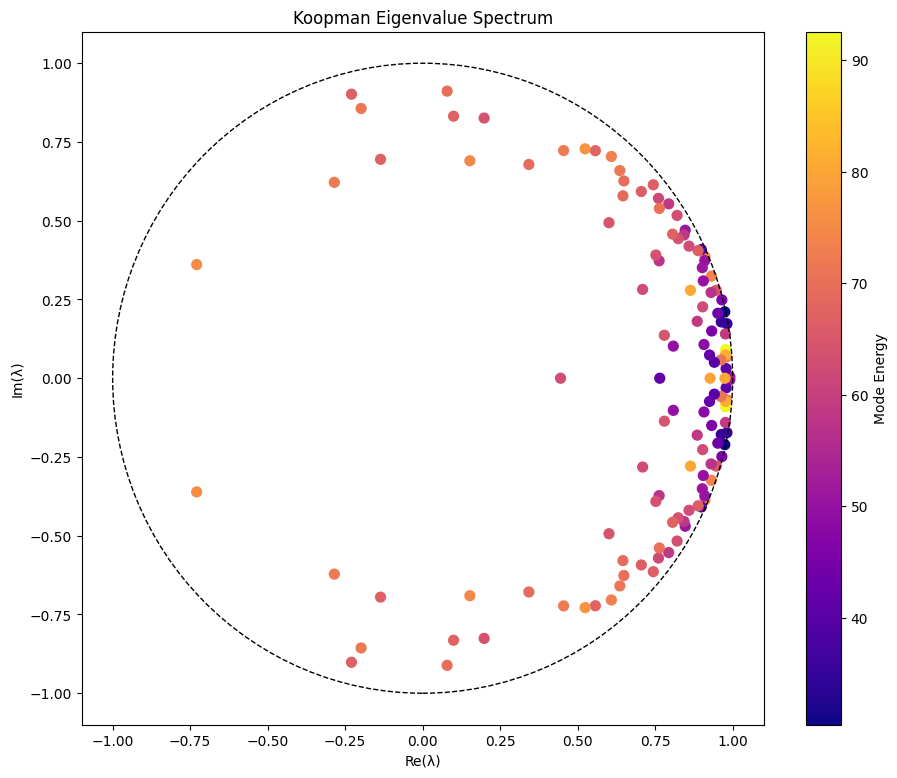

128


In [7]:
results_path = os.path.join("..", "results")
run_name_list = [
    #"L128_train_batch_nobias_wlin1",
    #"L128_train_layer_nobias_wlin1",
    #"L128_dmd_batch_norm_nobias_wlin0.1",
    #"L128_dmd_batch_norm_nobias_wlin1",
    #"L128_dmd_none_batch_none_nobias_wlin1",
    #"L128_dmd_layer_layer_nobias_wlin1",
    #"L128_dmd_layer_rms_nobias_wlin1",
    #"L128_train_layer_rms_nobias_wlin1",
    #"L128_dmd_none_layer_batch_nobias_wlin1",
    #"L128_dmd_none_batch_none_nobias_wlin1",
    #"L128_train_none_batch_none_nobias_wlin1",
    #"L128_train_none_batch_none_bias_wlin1",
    "L128_dmd_none_batch_batch_nobias_wlin1",
    #"L128_dmd_none_batch_rms_nobias_wlin1",
    #"L128_dmd_none_layer_none_nobias_wlin1",
    #"L128_dmd_none_none_none_nobias_wlin1",
    #"L128_dmd_none_none_none_nobias_wlin1_smalllr",
    #"L128_dmd_weightstd_standard_none_nobias_wlin1",
    #"L128_dmd_none_batch_none_nobias_wlin1_relerr",
    #"L128_dmd_none_none_none_nobias_wlin1_highlr",
    #"L128_dmd_weightstd_norm_none_nobias_wlin1_highlr"
    #"L128_dmd_weightstd_none_none_nobias_wlin1_AdamW",
    #"L128_dmd_weightstd_none_none_nobias_wlin2",
    #"L128_dmd_weightstd_none_none_nobias_wlin0.1",
    #"L128_dmd_weightstd_none_none_nobias_wlin0.01",
    #"L128_train_none_batch_none_nobias_wlin1",
    #"L128_train_none_batch_none_bias_wlin1",
    #"L128_train_batch_nonorm_nobias_wlin1",
    #"L16_train_batch_nonorm_nobias_wlin1",
    #"L16_dmd_batch_norm_nobias_wlin1",
    #"L128_dmd_batch_nonorm_nobias_wlin1",
    #"L128_dmd_batch_norm_nobias_wlin10",
    #"L128_dmd_batch_nobias_wlin100",
    #"L128_dmd_batch_nobias_wlin1000",
    #"L128_dmd_layer_nobias_wlin1",
    #"L128_dmd_layer_nobias_wlin10",
    #"L128_dmd_layer_nobias_wlin100",
    #"L128_dmd_layer_nobias_wlin1000",
    #"L128_train_batch_bias_wlin1",
    #"L128_train_layer_bias_wlin1",
    #"L128_dmd_batch_bias_wlin1",
    #"L128_dmd_layer_bias_wlin1",
]

CALCULATE_DMD_FOR_TRAINED = True
REDUCE_THRESHOLD = 1.0#0.0225

prediction_mse_windows = []

for run_name in run_name_list:
    print(run_name)
    run_path = os.path.join(results_path, "kae_experiments", run_name)
    
    hyperparam = run_name.split('_')
    
    LATENT_DIM = int(hyperparam[0][1:])
    koopman_type = hyperparam[1]
    weight_std = hyperparam[2] == "weightstd"
    print(weight_std)
    norm_type = hyperparam[3]
    norm_latent = hyperparam[4]
    use_bias = hyperparam[5] == "bias"

    model = ConvAutoencoder(latent_dim=LATENT_DIM, weight_standard=weight_std, bias_terms=use_bias, norm_type=norm_type, norm_latent=norm_latent).to(DEVICE)
    
    model.load_state_dict(torch.load(os.path.join(run_path, "model.pt"), map_location=DEVICE))
    model.eval()

    if koopman_type == "dmd" or CALCULATE_DMD_FOR_TRAINED:
        koopman_type = "dmd"
        K = torch.tensor(calculate_koopman(model, loader_train), device=DEVICE, requires_grad=False)
        #lin_weights = torch.tensor(K, device=DEVICE, requires_grad=True)
        #linfunction = lambda z_t : torch.nn.functional.linear(z_t, K)
    else:
        #linfunction = lambda z_t : model.linear_dynamics(z_t)
        with torch.no_grad():
            K = model.linear_dynamics.weight.detach()#.cpu().numpy()
    
    K_numpy = K.cpu().numpy()
    eigvalues, eigvectors = get_sorted_eigen(K_numpy)
    eigenergies = eigenvalue_energies(model, eigvectors, DEVICE)
    plot_eigenvalue_spectrum(eigvalues, eigenergies)

    predictor, eigenvalues_reduced = get_multi_step_predictor_K(K=K, threshold=REDUCE_THRESHOLD)
    num_eigenvalues = eigenvalues_reduced.cpu().numpy().shape[0]
    print(num_eigenvalues)
    #break
    
    prediction_window_path = os.path.join(run_path,"pred_window"+str(PREDICTION_WINDOW)+"_mse_"+koopman_type+"_"+str(num_eigenvalues)+".npy")
    if os.path.exists(prediction_window_path):
        prediction_mse = np.load(prediction_window_path)
    else:
        prediction_mse = np.zeros((window_offset_data.shape[0], PREDICTION_WINDOW+1))
        with torch.no_grad():
            for j, x_t in tqdm(enumerate(loader_full), total=len(dataset_full)):
                x_t = x_t.to(DEVICE)
                z_t = model.encoder(x_t).squeeze(0)
                z_trajectory = predictor(z_t, PREDICTION_WINDOW)
                X_prediction = model.decoder(z_trajectory).cpu().numpy()
                #X_prediction = predict_window(x_t, model, linfunction, PREDICTION_WINDOW)
                mse_window = np.mean((full_data[j:j+PREDICTION_WINDOW+1] - X_prediction)**2, axis=(1,2,3))
                prediction_mse[j] = mse_window
        np.save(prediction_window_path[:-4], prediction_mse)
    prediction_mse_windows.append(prediction_mse)
            
    
    
    #
    #break

In [37]:
positive_mask = np.angle(eigvalues) >= 0

In [53]:
mode_angles = np.angle(eigvalues)[positive_mask]

In [55]:
mode_angles.shape

(66,)

In [45]:
all_modes = torch.tensor(eigvectors[positive_mask].real, device=DEVICE)

In [47]:
with torch.no_grad():
    mode_structure = model.decoder(all_modes).cpu().numpy()

In [61]:
mode_energies = np.mean(mode_structure**2, axis=(1,2,3))

In [62]:
mode_energies.shape

(66,)

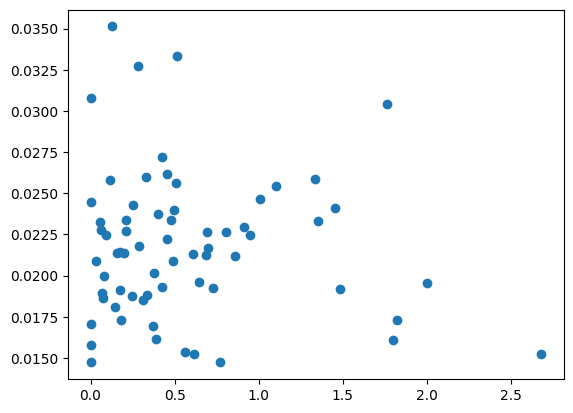

In [63]:
plt.scatter(mode_angles, mode_energies)

In [9]:
mask = eigvalues.real < -0.5

In [19]:
mode_tensor = torch.tensor(eigvectors[mask][0].real, device=DEVICE).unsqueeze(0)

In [20]:
mode_tensor

tensor([[-0.0938, -0.0938,  0.0549,  0.0549,  0.1010,  0.1010, -0.0350, -0.0350,
         -0.0504, -0.0504, -0.0420, -0.0420, -0.0721, -0.0721, -0.0586, -0.0586,
          0.0879,  0.0879, -0.0012, -0.0012,  0.0580,  0.0580,  0.0066,  0.0066,
          0.0633,  0.0633,  0.0148,  0.0148,  0.0754,  0.0754,  0.0296,  0.0296,
         -0.0421, -0.0320, -0.0320,  0.0191,  0.0191,  0.0410,  0.0410, -0.0017,
         -0.0017,  0.0718,  0.0718, -0.1148, -0.1148, -0.0244, -0.0244,  0.0656,
          0.0656, -0.0016, -0.0016, -0.1054, -0.1054,  0.0694,  0.0694, -0.0046,
         -0.0046,  0.0719,  0.0719,  0.1087,  0.1087, -0.0246, -0.0246,  0.0371,
          0.0371,  0.0041,  0.0041, -0.0535, -0.0535,  0.0033,  0.0033, -0.0357,
         -0.0357,  0.1184,  0.0342,  0.0342, -0.0619, -0.0619, -0.0633, -0.0633,
          0.0498,  0.0498,  0.0619,  0.0619, -0.0401, -0.0401, -0.0113, -0.0113,
          0.0312,  0.0312,  0.0838,  0.0838, -0.0463, -0.0463,  0.0252,  0.0252,
         -0.0823, -0.0823,  

In [31]:
with torch.no_grad():
    mode_structure = model.decoder(mode_tensor).cpu().numpy().squeeze(0)

In [32]:
vx, vz = mode_structure[0], mode_structure[1]

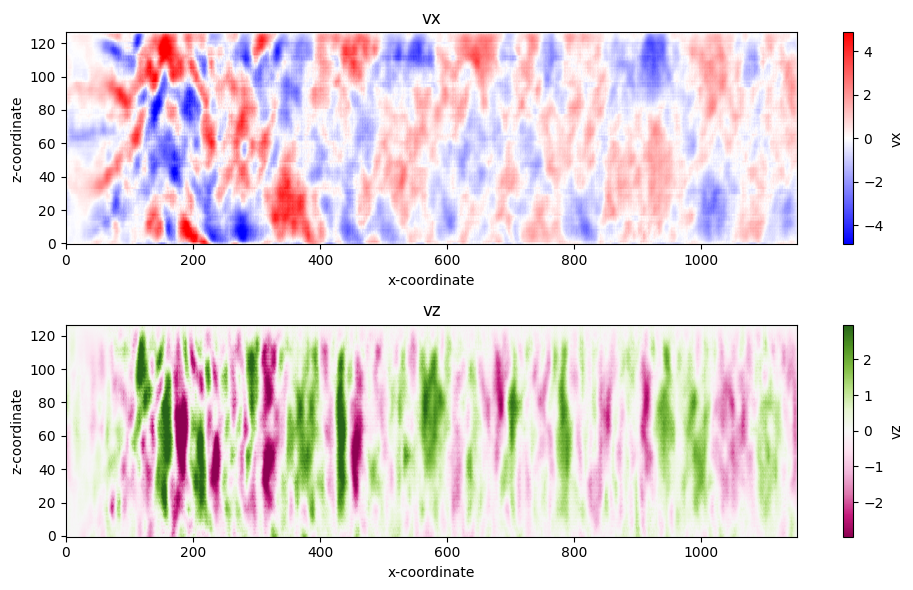

In [33]:
plot_vx_vz(vx*10, vz*10, norm_x, norm_z)

In [21]:
run_name_list = ["Koopman Autoencoder"]

In [22]:
dmd_prediction = np.load("dmd_prediction100.npy")

In [23]:
prediction_mse_windows.append(dmd_prediction)
run_name_list.append("SVD-DMD Baseline")

In [20]:
steady_tolerance = 0.015

stable_values, stable_vectors, stable_energies = get_stable_modes(eigvalues, eigvectors, eigenergies, steady_tolerance, False)

58 stable mode explain: 48.46% of the energy


In [ ]:
mode_values, mode_vectors, mode_energies = filter_pos_imag(stable_values, stable_vectors, stable_energies)
stable_structures = calculate_eigenmode_structures(mode_vectors, model, device=DEVICE)
for i, structure in enumerate(stable_structures):
    print(mode_values[i].item(),"\t", np.abs(mode_values[i].item()))
    print(mode_energies[i])
    vx = structure[0,:]
    vz = structure[1,:]
    plot_vx_vz(vx*3, vz*3, norm_x, norm_z)

In [ ]:
x_t = dataset_full[1147]
x_t = x_t.to(DEVICE).unsqueeze(0)
X_prediction = predict_window(x_t, model, linfunction, prediction_window)

In [ ]:
#example_index = 0
#
#vx = original_data[example_index, :, :, 0]
#vz = original_data[example_index, :, :, 1]
#
#plot_vx_vz(vx, vz, norm_x, norm_z)
#animate_trajectory(X_prediction+np.moveaxis(temp_mean, -1, 0), "prev_index_mode", norm_x, norm_z)


In [24]:
global_mse_list = []

for i, windowed_mse in enumerate(prediction_mse_windows):
    #if run_name_list[i] != "L128_e300_lamlin10_train":
    global_mse_list.append(np.mean(windowed_mse, 0))

In [25]:
train_mean_mse = []
test_mean_mse = []

for i, windowed_mse in enumerate(prediction_mse_windows):
    #if run_name_list[i] != "L128_e300_lamlin10_train":
    train_mean_mse.append(np.mean(windowed_mse[:train_test_cutoff], 0))
    test_mean_mse.append(np.mean(windowed_mse[train_test_cutoff:], 0))

In [26]:
mean_mse_list = []

for i, windowed_mse in enumerate(prediction_mse_windows):
    #if run_name_list[i] != "L128_e300_lamlin10_train":
    mean_mse_list.append(np.mean(windowed_mse, 1))

In [27]:
train_test_name_list = [name+" (train)" for name in run_name_list]+[name+" (test)" for name in run_name_list]

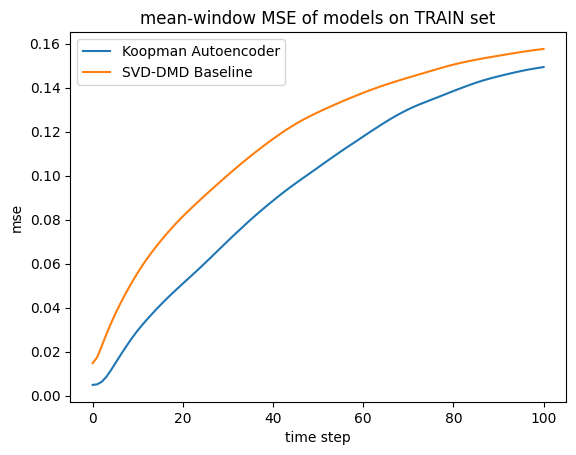

In [34]:
plot_evolution(train_mean_mse, [name for name in run_name_list], "mean-window MSE of models on TRAIN set", "time step", "mse")
plt.yscale("linear")

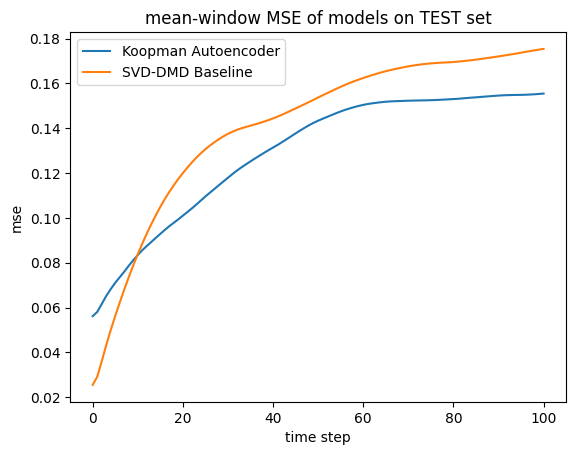

In [29]:
plot_evolution(test_mean_mse, [name for name in run_name_list], "mean-window MSE of models on TEST set", "time step", "mse")
plt.yscale("linear")

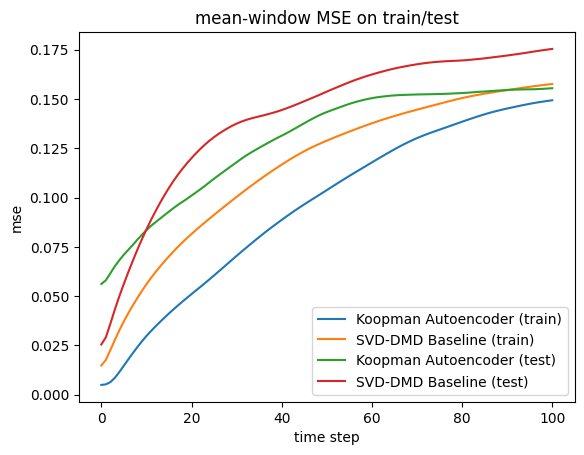

In [30]:
plot_evolution(train_mean_mse + test_mean_mse, train_test_name_list, "mean-window MSE on train/test", "time step", "mse")
plt.yscale("linear")

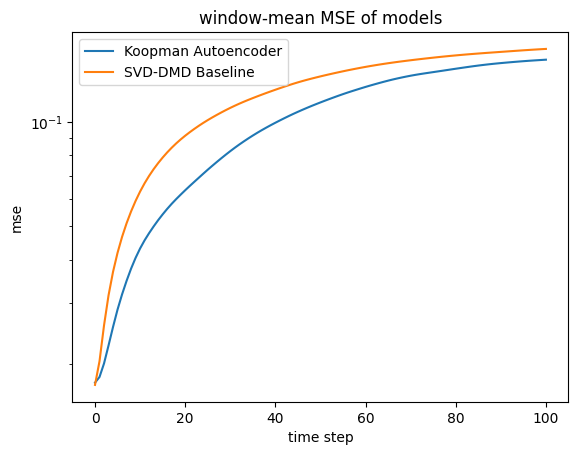

In [31]:
plot_evolution(global_mse_list, run_name_list, "window-mean MSE of models", "time step", "mse")

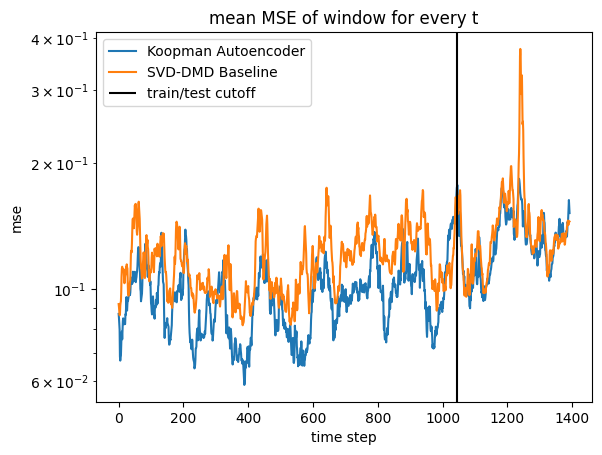

In [32]:
plot_evolution(mean_mse_list, run_name_list, "mean MSE of window for every t", "time step", "mse")
#plt.yscale("linear")
plt.vlines(train_test_cutoff, 0.05, 0.5, colors=["black"], label="train/test cutoff")
#plt.vlines(1219, 0.05, 0.5, colors=["red"], label="1219")
#plt.vlines(1119, 0.05, 0.5, colors=["orange"], label="1119")
plt.legend()

In [73]:
loss_history = pd.read_csv(os.path.join(run_path, "losses_history.csv"))

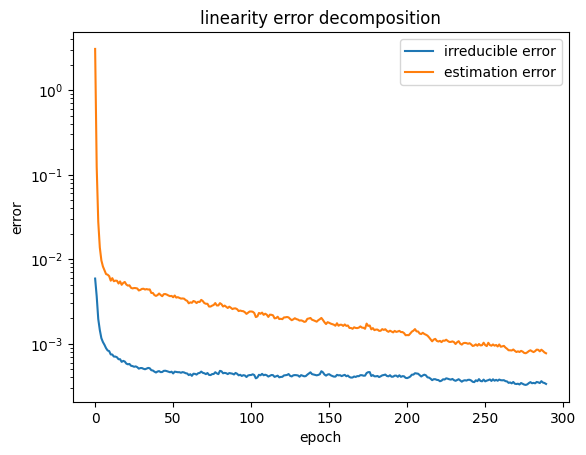

In [ ]:
plot_evolution([np.array(loss_history)[:,2][10:], np.array(loss_history)[:,3][10:]], ["irreducible error", "estimation error"], "linearity error decomposition", "epoch", "error")

In [96]:
np.array(loss_history)[:,3][10:] / (np.array(loss_history)[:,2][10:] + np.array(loss_history)[:,3][10:])

array([0.9980819 , 0.97136153, 0.9340003 , 0.90450224, 0.89270609,
       0.88682684, 0.88405558, 0.88264966, 0.88733079, 0.88514494,
       0.88169569, 0.88890891, 0.88614273, 0.88781116, 0.88932928,
       0.88715861, 0.89271169, 0.89077393, 0.89310439, 0.89728163,
       0.89603083, 0.89491675, 0.89494703, 0.89307432, 0.89243825,
       0.89520967, 0.89394743, 0.89509584, 0.89367482, 0.89368189,
       0.89619594, 0.89846415, 0.89766862, 0.89712424, 0.89419697,
       0.89546836, 0.89123517, 0.89212884, 0.88945867, 0.88957756,
       0.88915184, 0.89217848, 0.89096609, 0.88737036, 0.88980562,
       0.88975899, 0.8893661 , 0.88851231, 0.8882133 , 0.88741404,
       0.88854832, 0.88833498, 0.88346721, 0.88528601, 0.88320435,
       0.88293366, 0.88149828, 0.881743  , 0.87989982, 0.87858405,
       0.87597081, 0.87615471, 0.87974391, 0.87873417, 0.87745909,
       0.87520821, 0.87521647, 0.87331576, 0.87580595, 0.87587123,
       0.87117178, 0.87171703, 0.86823284, 0.86563155, 0.86608